## load necessary libraries

In [74]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

## load datasets

In [75]:
# ========== Load and Prepare Data ==========
#source_profiles = pd.read_excel("D:/IIITK_final/IIITK/Fog_SKD/Heavymetal_sources_new1.xlsx", sheet_name="Sheet2")
source_profiles = pd.read_excel("D:/IIITK_final/IIITK/Fog_SKD/Heavymetal_sources_new_mout.xlsx", sheet_name="Sheet2")
fog_samples = pd.read_excel("D:/IIITK_final/IIITK/Fog_SKD/New_data/IGP_test_bihar.xlsx")

In [76]:
# Set index
source_profiles = source_profiles.set_index("Element")
fog_samples = fog_samples.set_index("Sample ID")

In [77]:
# Match common elements
common_elements = source_profiles.index.intersection(fog_samples.columns)
#S = source_profiles.loc[common_elements].T  # shape: (sources, elements)
S = source_profiles.loc[common_elements]  # shape: (elements, sources)
B = fog_samples[common_elements]            # shape: (samples, elements)

In [78]:
S

,Coal,Fuel oil/Traffic,Crust,Industry average,Biomass/Wood burning
K,337000,0,2090,3.000000e+02,50280
Ca,2774000,139000,4150,6.500000e+03,40
Na,618300,1393750,2360,9.000000e+03,560
Mg,378600,9200,2330,3.136000e+05,20
Mn,19800,0,950000,4.212100e+05,2400
Cu,39500,0,55000,1.140000e+05,2200
As,39200,270,1800,1.000000e+03,200
Cd,0,2800,200,1.400000e+04,40
Pb,25000,2300,12500,1.020183e+07,1160


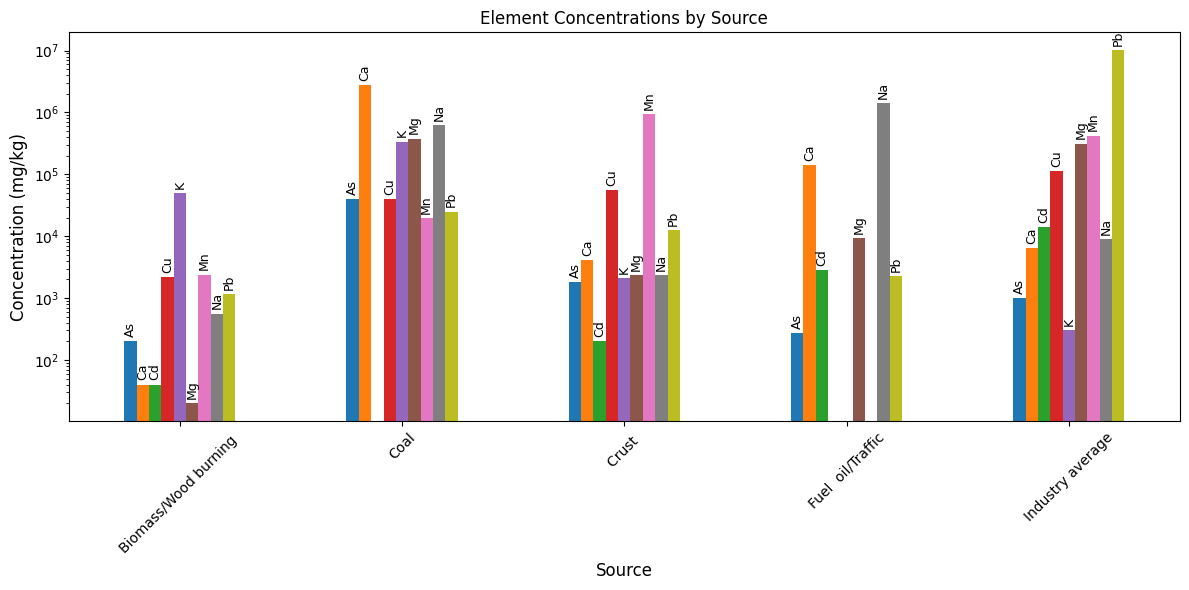

In [79]:
# Prepare for bar plotting
df_long = S.reset_index().melt(id_vars='index', var_name='Source', value_name='Concentration').rename(columns={'index': 'Element'})
pivot_df = df_long.pivot(index='Source', columns='Element', values='Concentration')

fig, ax = plt.subplots(figsize=(12, 6))
bars = pivot_df.plot(kind='bar', logy=True, ax=ax)

plt.title('Element Concentrations by Source', fontsize=12)
plt.xlabel('Source', fontsize=12)
plt.ylabel('Concentration (mg/kg)', fontsize=12)
plt.xticks(rotation=45)

# Annotate element names above each bar
for container, element in zip(ax.containers, pivot_df.columns):
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.annotate(
                f'{element}',
                (bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center',
                va='bottom',
                fontsize=9,
                rotation=90,
                color='black'
            )

# Hide legend
ax.legend_.remove()
plt.tight_layout()
#plt.savefig("D:/IIITK_final/IIITK/Fog_SKD/source_data.png",bbox_inches = 'tight', dpi = 300)
plt.show()

In [80]:
# normalize source dataset
def normalize_rows_df(df: pd.DataFrame) -> pd.DataFrame:
    # Sum per row
    row_sums = df.sum(axis=1)
    row_sums[row_sums == 0] = 1
    df_normalized = df.div(row_sums, axis=0)
    return df_normalized# Example with Pandas DataFrame

In [81]:
S_norm = normalize_rows_df(S)

In [82]:
S_norm

,Coal,Fuel oil/Traffic,Crust,Industry average,Biomass/Wood burning
K,0.864834,0.000000,0.005364,0.000770,0.129032
Ca,0.948801,0.047543,0.001419,0.002223,0.000014
Na,0.305489,0.688622,0.001166,0.004447,0.000277
Mg,0.537975,0.013073,0.003311,0.445613,0.000028
Mn,0.014210,0.000000,0.681781,0.302287,0.001722
Cu,0.187470,0.000000,0.261035,0.541054,0.010441
As,0.923004,0.006357,0.042383,0.023546,0.004709
Cd,0.000000,0.164319,0.011737,0.821596,0.002347
Pb,0.002441,0.000225,0.001220,0.996001,0.000113


In [83]:
B

,K,Ca,Na,Mg,Mn,Cu,As,Cd,Pb
Sample ID,,,,,,,,,
M01,2251,19018.0,12254.0,1332,16.463000,3.958000,0.701000,0.478000,4.384000
M02,860,3739.0,2900.0,449,6.538000,3.418000,0.127000,0.418000,2.952000
M03,722,4164.0,4014.0,540,11.146000,2.512000,0.147000,0.474000,2.516000
M04,1153,11909.0,5824.0,795,8.359000,9.890000,0.564000,0.522000,2.557000
M05,1935,12021.0,8214.0,1111,13.224000,7.815000,0.598000,0.453000,4.362000
M06,799,4850.0,3933.0,467,5.608000,3.493000,0.190000,0.164000,2.181000
M07,1347,8778.0,6093.0,590,7.110000,5.258000,0.271000,0.362000,3.670000
M08,2305,13991.0,8198.0,1083,46.363000,11.716000,1.487000,0.840000,7.665000
M09,2092,14023.0,9388.0,847,15.072000,4.875000,1.161000,0.428000,4.440000


## data augmentation

In [84]:
# Function to add noise
def augment_unsupervised_data(df, n_augments=10, noise_level=0.05):
    synthetic_data = []
    
    for _ in range(n_augments):
        noisy_df = df + np.random.normal(loc=0.0, scale=noise_level, size=df.shape)
        noisy_df = pd.DataFrame(noisy_df, columns=df.columns)
        synthetic_data.append(noisy_df)

    df_aug = pd.concat(synthetic_data + [df], ignore_index=True)
    return df_aug

# Generate 10 noisy versions → final dataset: 11 × (1+10) = 121 rows
B_augmented = augment_unsupervised_data(B, n_augments=10, noise_level=0.05)

In [85]:
B_augmented

,K,Ca,Na,Mg,Mn,Cu,As,Cd,Pb
0,2250.992617,19017.996496,12254.048113,1331.965611,16.427797,3.902170,0.715264,0.547045,4.389310
1,860.077460,3738.927031,2899.966763,449.068114,6.525800,3.439832,0.051671,0.384181,2.951788
2,721.936547,4164.038537,4014.042202,539.974137,11.073093,2.513023,0.179798,0.497100,2.480610
3,1152.977998,11909.061011,5824.054743,794.999138,8.315687,9.880441,0.648171,0.560343,2.642886
4,1934.950407,12020.869761,8213.978910,1110.981376,13.288390,7.844067,0.656335,0.410679,4.342066
...,...,...,...,...,...,...,...,...,...
226,2197.000000,6110.000000,1252.000000,694.000000,13.247568,0.435061,0.518654,0.076857,0.436541
227,834.000000,2774.000000,523.000000,281.000000,8.913263,0.911796,0.732502,0.339337,2.209108
228,2613.000000,7878.000000,815.000000,771.000000,63.106824,3.384211,3.267257,0.819575,3.122012
229,1707.000000,8001.000000,1634.000000,657.000000,46.282162,1.356401,1.541880,0.328001,1.101039


In [86]:
B.iloc[:,:4]

,K,Ca,Na,Mg
Sample ID,,,,
M01,2251,19018.0,12254.0,1332
M02,860,3739.0,2900.0,449
M03,722,4164.0,4014.0,540
M04,1153,11909.0,5824.0,795
M05,1935,12021.0,8214.0,1111
M06,799,4850.0,3933.0,467
M07,1347,8778.0,6093.0,590
M08,2305,13991.0,8198.0,1083
M09,2092,14023.0,9388.0,847


In [87]:
B.shape[1]

9

In [88]:
# ---- 2. Statistical Comparison ----
def compare_statistics(df1, df2):
    stat_df = pd.DataFrame({
        'mean_original': df1.mean(),
        'mean_augmented': df2.mean(),
        'std_original': df1.std(),
        'std_augmented': df2.std(),
        'corr': [df1[col].corr(df2[col]) for col in df1.columns]
    })
    print("Statistical Comparison:\n", stat_df)
    return stat_df

In [89]:
stat_df = compare_statistics(B, B_augmented)

Statistical Comparison:
     mean_original  mean_augmented  std_original  std_augmented  corr
K     1856.142857     1856.137198   1273.851023    1245.849651   NaN
Ca    9007.095238     9007.093933   5088.861561    4977.004253   NaN
Na    3825.000000     3824.998523   3320.966922    3247.971264   NaN
Mg     789.714286      789.711310    397.838679     389.094024   NaN
Mn      22.625184       22.630142     24.009083      23.484154   NaN
Cu       3.660462        3.661953      3.108364       3.034069   NaN
As       0.885375        0.885329      0.770100       0.752160   NaN
Cd       0.342480        0.340711      0.237648       0.233250   NaN
Pb       2.392415        2.393885      1.990119       1.946776   NaN


In [90]:
# ---- 5. Visualization ----
def plot_feature_trends(df1, df2, num_features=9):
    for col in df1.columns[:num_features]:
        plt.figure(figsize=(8, 4))
        plt.plot(df1[col].values, label='Original', marker='o')
        plt.plot(df2[col].values[:len(df1)], label='Augmented (first 11)', linestyle='--')
        plt.title(f"Trend Comparison: {col}")
        plt.legend()
        plt.grid(True)
        plt.show()

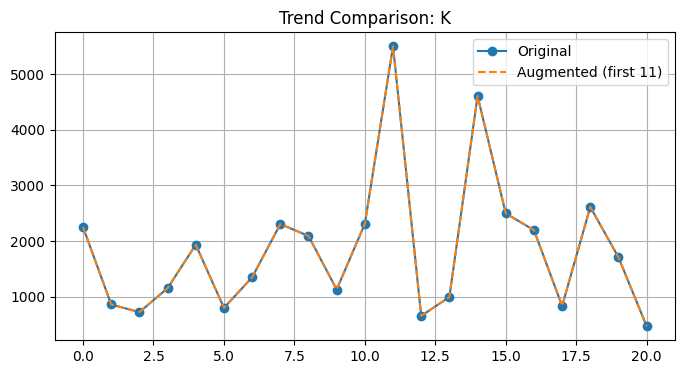

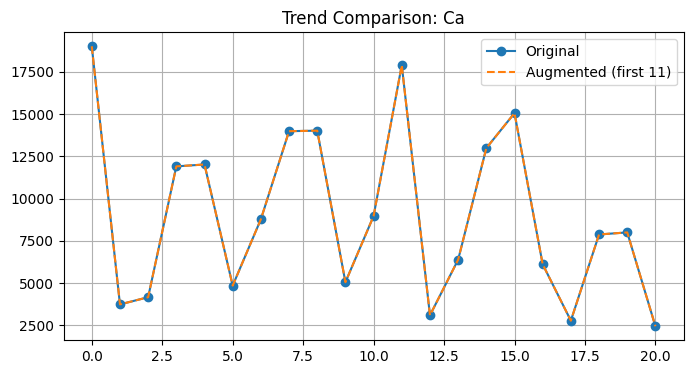

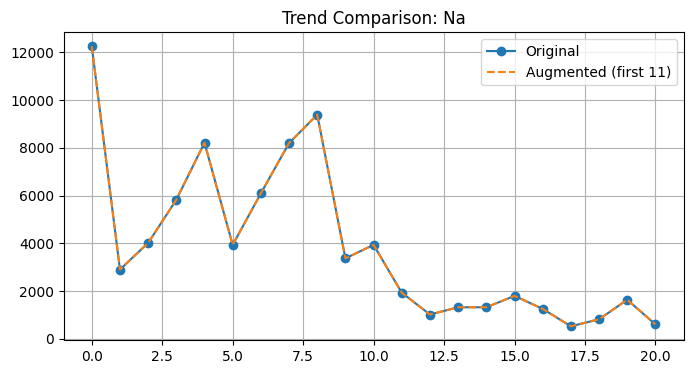

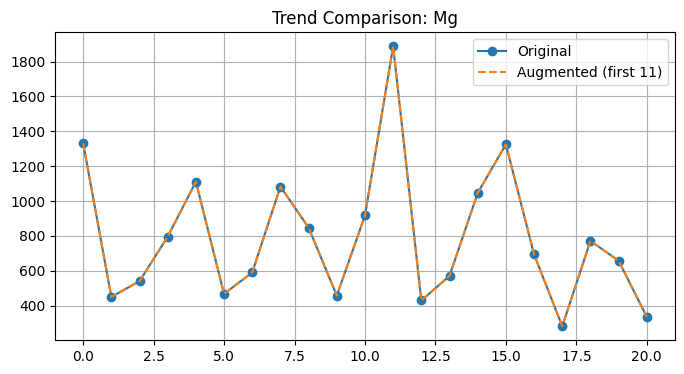

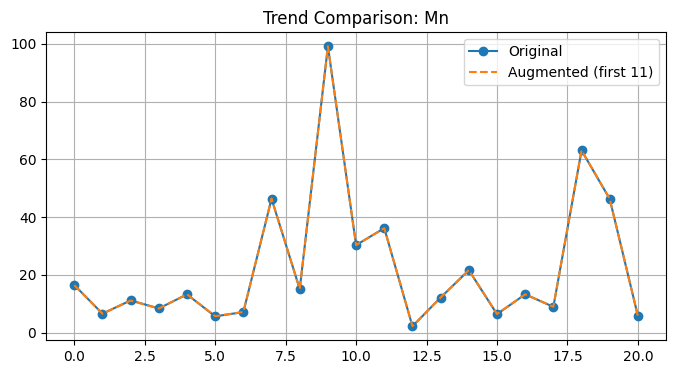

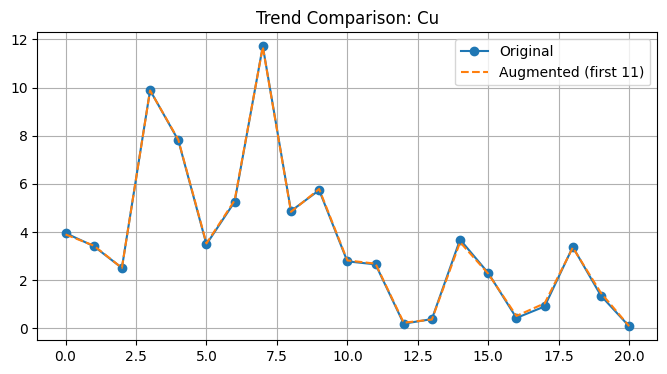

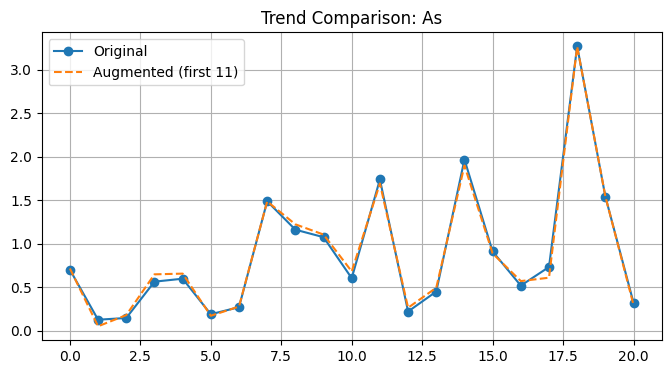

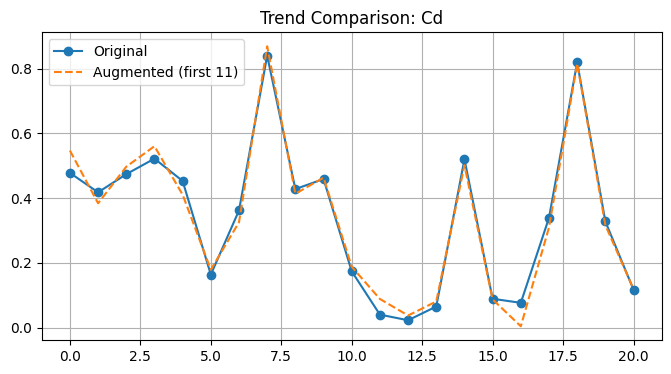

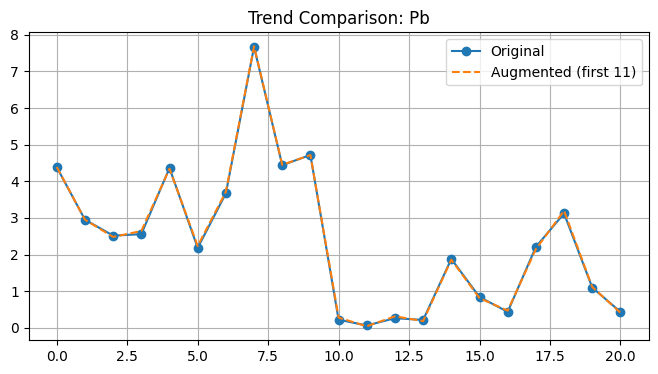

In [91]:
plot_feature_trends(B, B_augmented)

In [92]:
B.index

Index(['M01', 'M02', 'M03', 'M04', 'M05', 'M06', 'M07', 'M08', 'M09', 'M10',
       'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10',
       'A11'],
      dtype='object', name='Sample ID')

In [93]:
ones1 = np.ones(5, dtype = None, order = 'F')

In [94]:
ones1

array([1., 1., 1., 1., 1.])

In [95]:
S_matrix = np.vstack([S_norm,ones1])

In [96]:
S_matrix

array([[8.64834347e-01, 0.00000000e+00, 5.36351272e-03, 7.69882208e-04,
        1.29032258e-01],
       [9.48801001e-01, 4.75426601e-02, 1.41943913e-03, 2.22321792e-03,
        1.36813410e-05],
       [3.05488718e-01, 6.88621867e-01, 1.16602519e-03, 4.44670623e-03,
        2.76683943e-04],
       [5.37975133e-01, 1.30728242e-02, 3.31083481e-03, 4.45612789e-01,
        2.84191829e-05],
       [1.42097444e-02, 0.00000000e+00, 6.81780668e-01, 3.02287195e-01,
        1.72239327e-03],
       [1.87470337e-01, 0.00000000e+00, 2.61034646e-01, 5.41053631e-01,
        1.04413859e-02],
       [9.23004474e-01, 6.35742877e-03, 4.23828585e-02, 2.35460325e-02,
        4.70920650e-03],
       [0.00000000e+00, 1.64319249e-01, 1.17370892e-02, 8.21596244e-01,
        2.34741784e-03],
       [2.44074045e-03, 2.24548121e-04, 1.22037022e-03, 9.96001091e-01,
        1.13250357e-04],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00]])

## Normalisation of sample data

In [97]:
from sklearn.preprocessing import MinMaxScaler
scaler_x=MinMaxScaler(feature_range=(0, 1)).fit(B_augmented)

In [98]:
B_scaled = scaler_x.transform(B_augmented)

In [99]:
#B_scaled = B_scaled.T

In [100]:
# Create a column of ones with same number of rows
ones = np.ones((B_scaled.shape[0], 1))

# Add the ones column to A
B_matrix = np.hstack((B_scaled, ones))


In [101]:
B_matrix.shape

(231, 10)

In [102]:
S_matrix.shape

(10, 5)

In [103]:
# Prepare data
B_input = B_matrix[:210]                          # (samples × elements)
B_test = B_matrix[210:]
#Y_target = np.linalg.pinv(S_matrix) @ X_input  # (samples × sources)

In [104]:
#Define objective functions

def objective(x):
    return np.linalg.norm(S_matrix @ x - b)**2

In [105]:
bounds = [(1e-6, None)] * S_matrix.shape[1]  # Enforce x_i > 0

In [106]:
x0 = np.ones(S_matrix.shape[1])  # Initial guess (1 for each source)

In [107]:
from scipy.optimize import minimize

In [108]:
X = []
for b in B_input:
    result = minimize(objective, x0=np.ones(S_matrix.shape[1]), bounds=bounds)
    X.append(result.x)

X = np.array(X)  # shape (samples x sources)

In [109]:
Y_target = X

In [110]:
Y_target

array([[5.04434981e-01, 4.86645049e-01, 1.00000000e-06, 4.15559149e-01,
        1.00000000e-06],
       [1.56290084e-02, 3.02199259e-01, 1.00000000e-06, 4.10721109e-01,
        2.75697487e-01],
       [3.72888594e-02, 4.66947814e-01, 1.00000000e-06, 4.10404316e-01,
        8.63071844e-02],
       ...,
       [4.78083797e-01, 1.00000000e-06, 2.21494809e-01, 5.07443153e-01,
        1.00000000e-06],
       [3.31892916e-01, 3.32666074e-02, 4.14379335e-01, 2.42842851e-01,
        1.00000000e-06],
       [1.00000000e-06, 9.12184759e-02, 1.00000000e-06, 1.48251024e-01,
        7.47943860e-01]])

In [111]:
Y_target_log = np.log1p(Y_target)

In [112]:
# Assuming y_train is a NumPy array of shape (97, 6)
Y_target_df = pd.DataFrame(Y_target, columns=[f'Target_{i}' for i in range(Y_target.shape[1])])

In [113]:
#Y_target_log

In [114]:
#y_train_transformed_df = pd.DataFrame(y_transformed, columns=[f'Target_{i}' for i in range(y_train_transformed.shape[1])])

## Model building

In [115]:
n_features = B_matrix.shape[1]
n_sources  = S_matrix.shape[1]

In [116]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

def build_mlp(n_features, n_sources, dropout=0.2, l2_reg=1e-4):
    inputs = layers.Input(shape=(n_features,))
    x = inputs
    x = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout)(x)
    # final layer: produce logits for softmax
    logits = layers.Dense(n_sources)(x)
    outputs = layers.Activation('relu')(logits)   # ensures non-negativity + sum=1
    model = models.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='mse',      
                  metrics=['mse'])
    return model

In [117]:
model = build_mlp(n_features, n_sources, dropout=0.2, l2_reg=1e-4)
es = callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
model.fit(B_input, Y_target, validation_split=0.1, epochs=1000, batch_size=16, callbacks=[es], verbose=1)

Epoch 1/1000
12/12 [==============================] - 1s 31ms/step - loss: 0.0748 - mse: 0.0730 - val_loss: 0.0469 - val_mse: 0.0451
Epoch 2/1000
12/12 [==============================] - 0s 10ms/step - loss: 0.0504 - mse: 0.0486 - val_loss: 0.0345 - val_mse: 0.0328
Epoch 3/1000
12/12 [==============================] - 0s 8ms/step - loss: 0.0374 - mse: 0.0357 - val_loss: 0.0243 - val_mse: 0.0227
Epoch 4/1000
12/12 [==============================] - 0s 9ms/step - loss: 0.0314 - mse: 0.0298 - val_loss: 0.0189 - val_mse: 0.0173
Epoch 5/1000
12/12 [==============================] - 0s 10ms/step - loss: 0.0242 - mse: 0.0226 - val_loss: 0.0164 - val_mse: 0.0148
Epoch 6/1000
12/12 [==============================] - 0s 8ms/step - loss: 0.0222 - mse: 0.0206 - val_loss: 0.0145 - val_mse: 0.0129
Epoch 7/1000
12/12 [==============================] - 0s 7ms/step - loss: 0.0195 - mse: 0.0179 - val_loss: 0.0119 - val_mse: 0.0103
Epoch 8/1000
12/12 [==============================] - 0s 10ms/step - loss

In [118]:
# ========== Predict B ==========
X_pred = model.predict(B_test)  # shape: (samples × sources)

1/1 [==============================] - 0s 52ms/step


In [119]:
X_pred.shape

(21, 5)

In [120]:
import numpy as np

print(np.sum(X_pred, axis=1))

[1.4019349  1.0231347  1.0047104  1.1360968  1.2420475  1.013373
 1.069385   1.3642058  1.2611451  1.2658831  1.0561388  1.1207075
 0.96419376 1.02797    1.0591662  0.98502    1.0059866  0.9484692
 1.1981282  0.9677627  0.98354113]


## Estimated Source apportionment (Without normalization)

In [121]:
# ========== Save B Matrix ==========
contributions_df = pd.DataFrame(X_pred, columns=S.columns)
#contributions_df.to_excel("D:/IIITK_final/IIITK/Fog_SKD/New_data/norm_mlp_marine_bihar.xlsx")
print("Estimated Source Contributions (X):")
print(contributions_df.round(4))

Estimated Source Contributions (X):
      Coal  Fuel  oil/Traffic  Crust   Industry average  Biomass/Wood burning 
0   0.5161             0.4933  0.0000            0.3925                 0.0000
1   0.0222             0.3275  0.0000            0.4187                 0.2548
2   0.0425             0.4458  0.0000            0.3984                 0.1181
3   0.3043             0.3210  0.0000            0.5107                 0.0000
4   0.3643             0.3476  0.0000            0.5302                 0.0000
5   0.0841             0.3786  0.0000            0.2816                 0.2691
6   0.1967             0.4513  0.0000            0.4214                 0.0000
7   0.4549             0.0000  0.0000            0.9093                 0.0000
8   0.4291             0.4167  0.0000            0.4153                 0.0000
9   0.0882             0.0000  0.6758            0.5019                 0.0000
10  0.3597             0.2498  0.2831            0.1635                 0.0000
11  0.9046      

In [122]:
X_pred.shape[0]

21

In [123]:
# ========== Reconstruct B ==========
B_hat = []
for i in range(X_pred.shape[0]):
    B_hat_i = S_matrix @ X_pred[i]
    B_hat.append(B_hat_i)
    
#B_hat = X_pred @ S_matrix
#B_hat_df = pd.DataFrame(B_hat)

In [124]:
B_hat

[array([0.44662339, 0.51398185, 0.49912627, 0.45899666, 0.12598623,
        0.30912198, 0.48872007, 0.40355597, 0.3923179 , 1.40193486]),
 array([0.05238542, 0.03754775, 0.23421387, 0.20277762, 0.12730745,
        0.23333245, 0.03361188, 0.39837204, 0.41713512, 1.02313477]),
 array([0.05231943, 0.06242933, 0.32175207, 0.20622606, 0.12122856,
        0.22474262, 0.05202242, 0.40081917, 0.39699015, 1.00471038]),
 array([0.26359967, 0.305159  , 0.31630933, 0.39551298, 0.15871135,
        0.33338689, 0.29497668, 0.47236329, 0.50950115, 1.13609684]),
 array([0.31547841, 0.36336378, 0.35300022, 0.43677997, 0.16543658,
        0.35514143, 0.35095517, 0.49268895, 0.52900458, 1.24204749]),
 array([0.10765649, 0.09840693, 0.28774551, 0.17565498, 0.08676843,
        0.17090835, 0.08791107, 0.29417166, 0.28074876, 1.01337296]),
 array([0.17044229, 0.20902856, 0.37275703, 0.29948389, 0.13016524,
        0.26485193, 0.19435079, 0.42034467, 0.42025108, 1.06938496]),
 array([0.39408135, 0.43359626, 0.

In [125]:
B_hat = np.array(B_hat)

In [126]:
# ========== Evaluate Reconstruction (MSE) ==========
mses = []
for i in range(B_test.shape[0]):
    mse = mean_squared_error(B_test[i], B_hat[i])
    mses.append(mse)
    print(f"\nReconstruction MSE: {mse:.4f}")
np.average(mses)


Reconstruction MSE: 0.0834

Reconstruction MSE: 0.0033

Reconstruction MSE: 0.0031

Reconstruction MSE: 0.0459

Reconstruction MSE: 0.0338

Reconstruction MSE: 0.0030

Reconstruction MSE: 0.0116

Reconstruction MSE: 0.0721

Reconstruction MSE: 0.0313

Reconstruction MSE: 0.0360

Reconstruction MSE: 0.0082

Reconstruction MSE: 0.0481

Reconstruction MSE: 0.0017

Reconstruction MSE: 0.0039

Reconstruction MSE: 0.0186

Reconstruction MSE: 0.0213

Reconstruction MSE: 0.0034

Reconstruction MSE: 0.0095

Reconstruction MSE: 0.0706

Reconstruction MSE: 0.0115

Reconstruction MSE: 0.0035


0.024948006815851267

In [127]:
B_hat.shape

(21, 10)

In [128]:
B_trimmed = B_hat[:, :-1]

In [129]:
B_trimmed.shape

(21, 9)

In [130]:
# To compare with real B,inverse transform is required:
B_inv_df = scaler_x.inverse_transform(B_trimmed)

In [131]:
B_hat_df = pd.DataFrame(B_inv_df, columns=B_augmented.columns)
B_hat_df

,K,Ca,Na,Mg,Mn,Cu,As,Cd,Pb
0,2716.307949,10962.766646,6378.277834,1018.603927,14.329203,3.635035,1.661192,0.326293,3.009060
1,731.658840,3066.241135,3270.544527,606.801810,14.457521,2.742186,0.159419,0.320872,3.201206
2,731.326653,3478.633957,4297.470350,612.344238,13.867133,2.640992,0.220171,0.323431,3.045235
3,1794.940943,7501.689949,4233.620566,916.571255,17.507504,3.920891,1.021875,0.398244,3.916345
4,2056.105731,8466.389022,4664.047848,982.896661,18.160665,4.177174,1.206593,0.419498,4.067349
5,1009.901128,4074.934748,3898.533541,563.209570,10.520326,2.006790,0.338597,0.211912,2.145243
6,1325.973644,5908.402430,4895.818324,762.230718,14.735073,3.113506,0.689828,0.343849,3.225331
7,2451.803926,9630.437928,2200.488706,1325.460699,29.417933,6.794068,1.504556,0.685544,6.992537
8,2337.919007,9536.162874,5448.957095,958.131007,14.877516,3.588133,1.396579,0.332684,3.182820
9,872.115171,3865.251070,874.438765,720.200162,61.697860,5.465366,0.450639,0.343783,3.849920


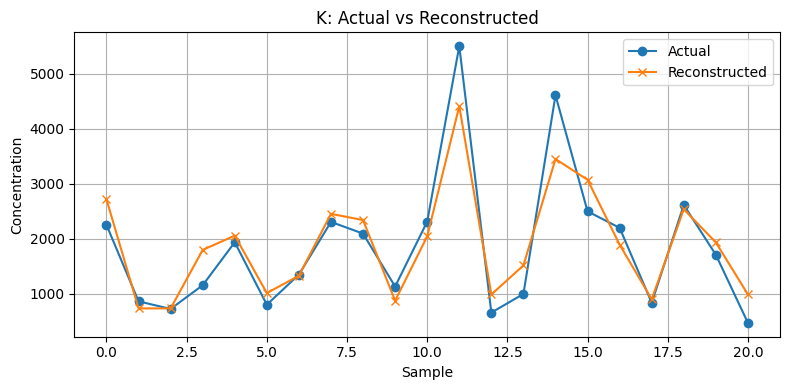

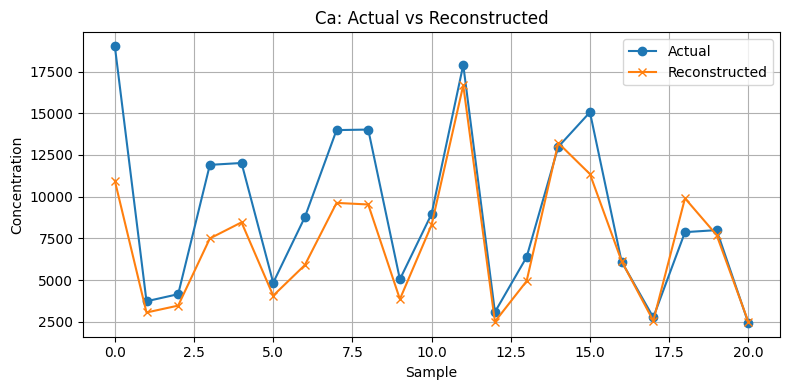

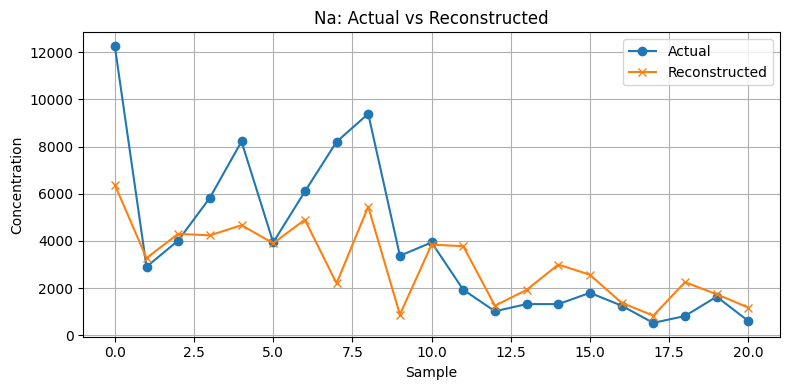

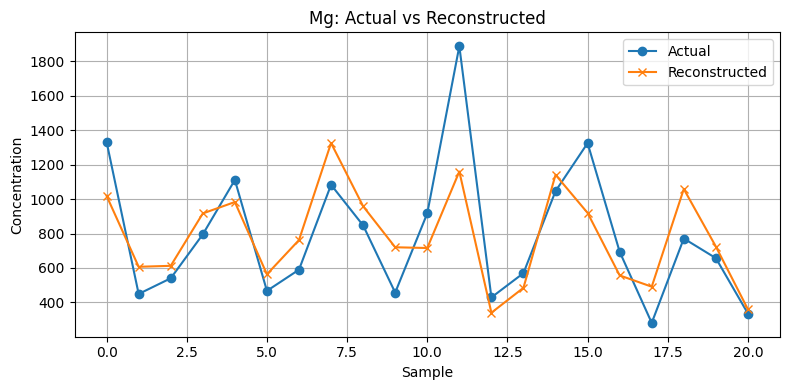

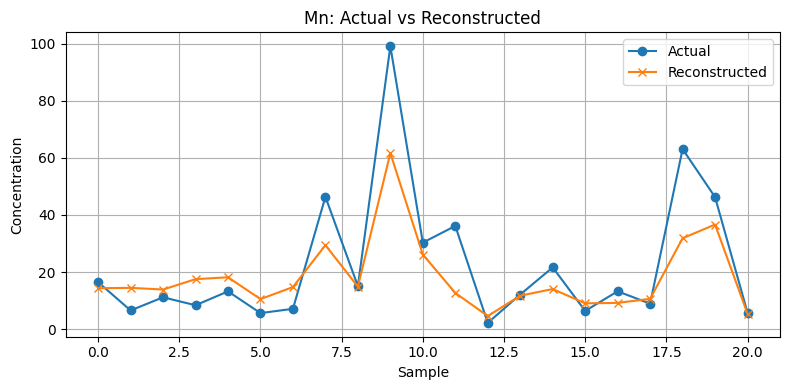

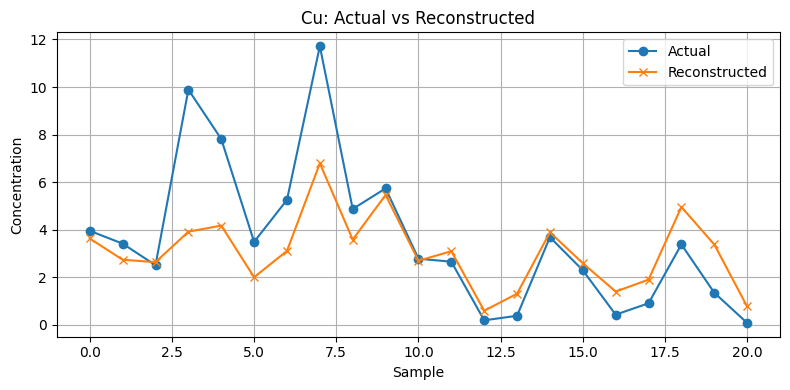

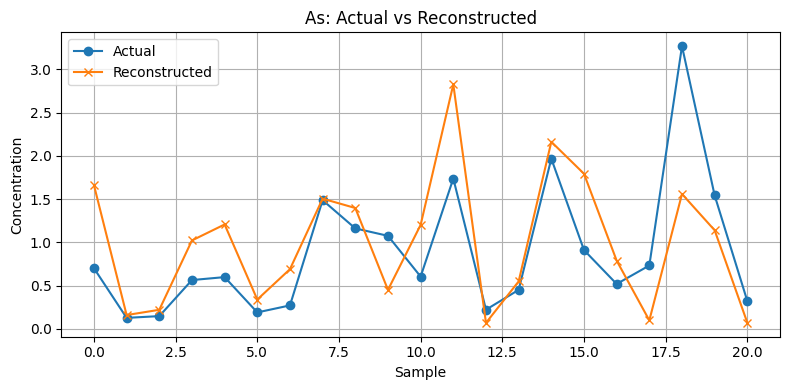

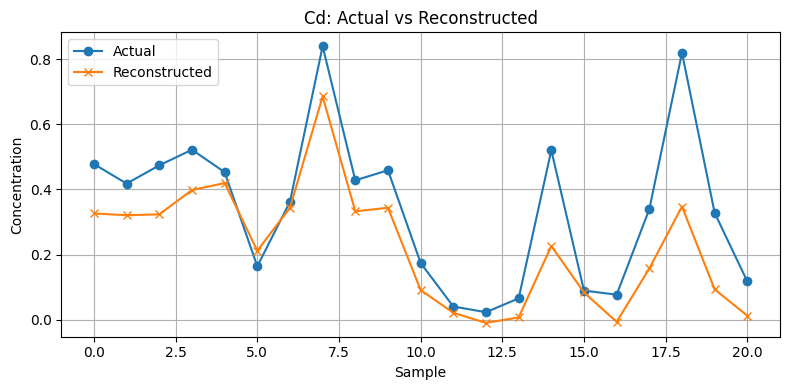

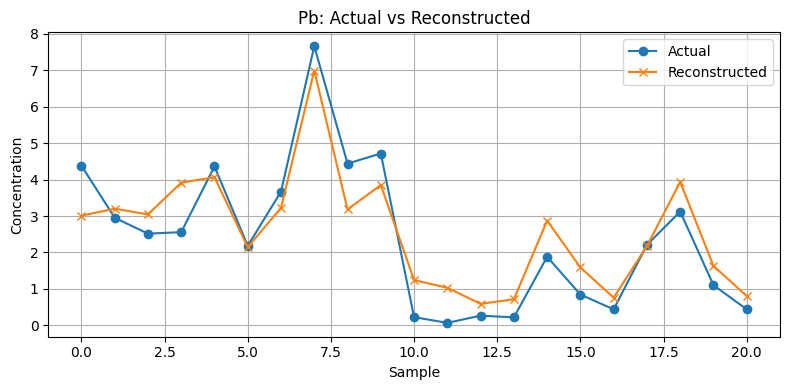

In [132]:
# ========== Optional: Plot Actual vs Reconstructed ==========
for element in B_augmented.columns[:9]:  # First 3 elements
    plt.figure(figsize=(8, 4))
    plt.plot(B_augmented[210:][element].values, label='Actual', marker='o')
    plt.plot(B_hat_df[element].values, label='Reconstructed', marker='x')
    plt.title(f'{element}: Actual vs Reconstructed')
    plt.xlabel("Sample")
    plt.ylabel("Concentration")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [133]:
from sklearn.metrics import r2_score

r2 = []
for col in B_augmented.columns:
    r2_sc=r2_score(B_augmented[210:][col], B_hat_df[col])
    r2.append(r2_sc)


print("R2 score:", r2)

R2 score: [0.8583895312283683, 0.6725167760069366, 0.46169141388401336, 0.6055768432423939, 0.6802992666204526, 0.5210401239574751, 0.31189722343788207, 0.515032273058044, 0.8460052447128158]


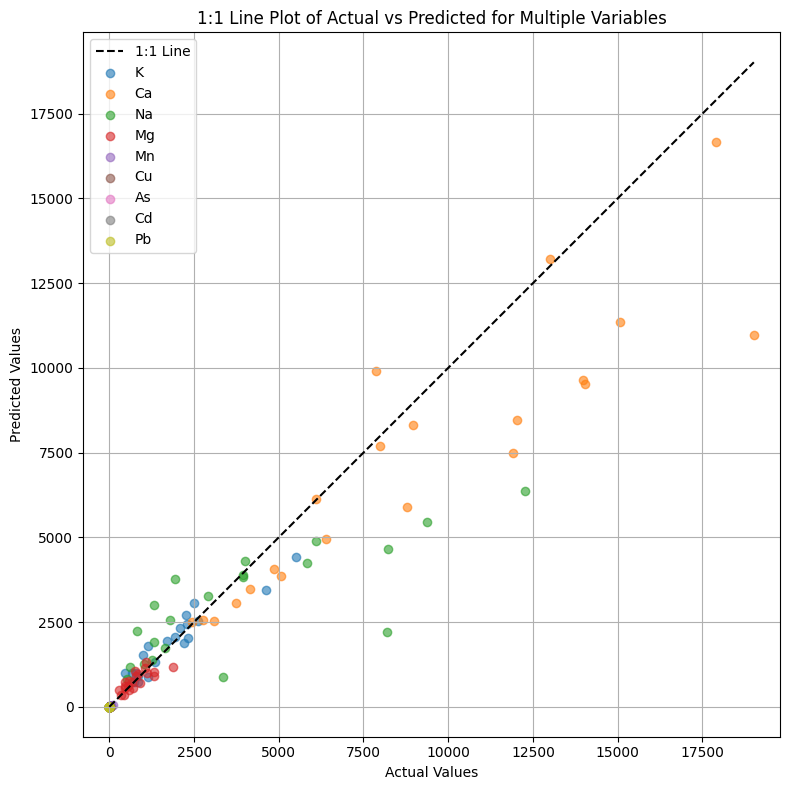

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Plot
plt.figure(figsize=(8, 8))
min_val = min(B_augmented[210:].min().min(),B_hat_df.min().min())
max_val = max(B_augmented[210:].max().max(), B_hat_df.max().max())

# 1:1 line
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 Line')

# Scatter plot for each variable
for col in B_augmented.columns:
    plt.scatter(B_augmented[210:][col], B_hat_df[col], label=col, alpha=0.6)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("1:1 Line Plot of Actual vs Predicted for Multiple Variables")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
#plt.savefig("D:/IIITK_final/IIITK/Fog_SKD/result_all_mlp_opt_marine.png",bbox_inches = 'tight', dpi = 300)
plt.show()

In [135]:
b_aug = np.asarray(B_augmented[210:])

In [136]:
b_aug = b_aug.flatten()

In [137]:
b_pred = np.asarray(B_hat_df)

In [138]:
b_pred = b_pred.flatten()

In [139]:
r2_all=r2_score(b_aug,b_pred)

In [140]:
r2_all

0.8726060614997001

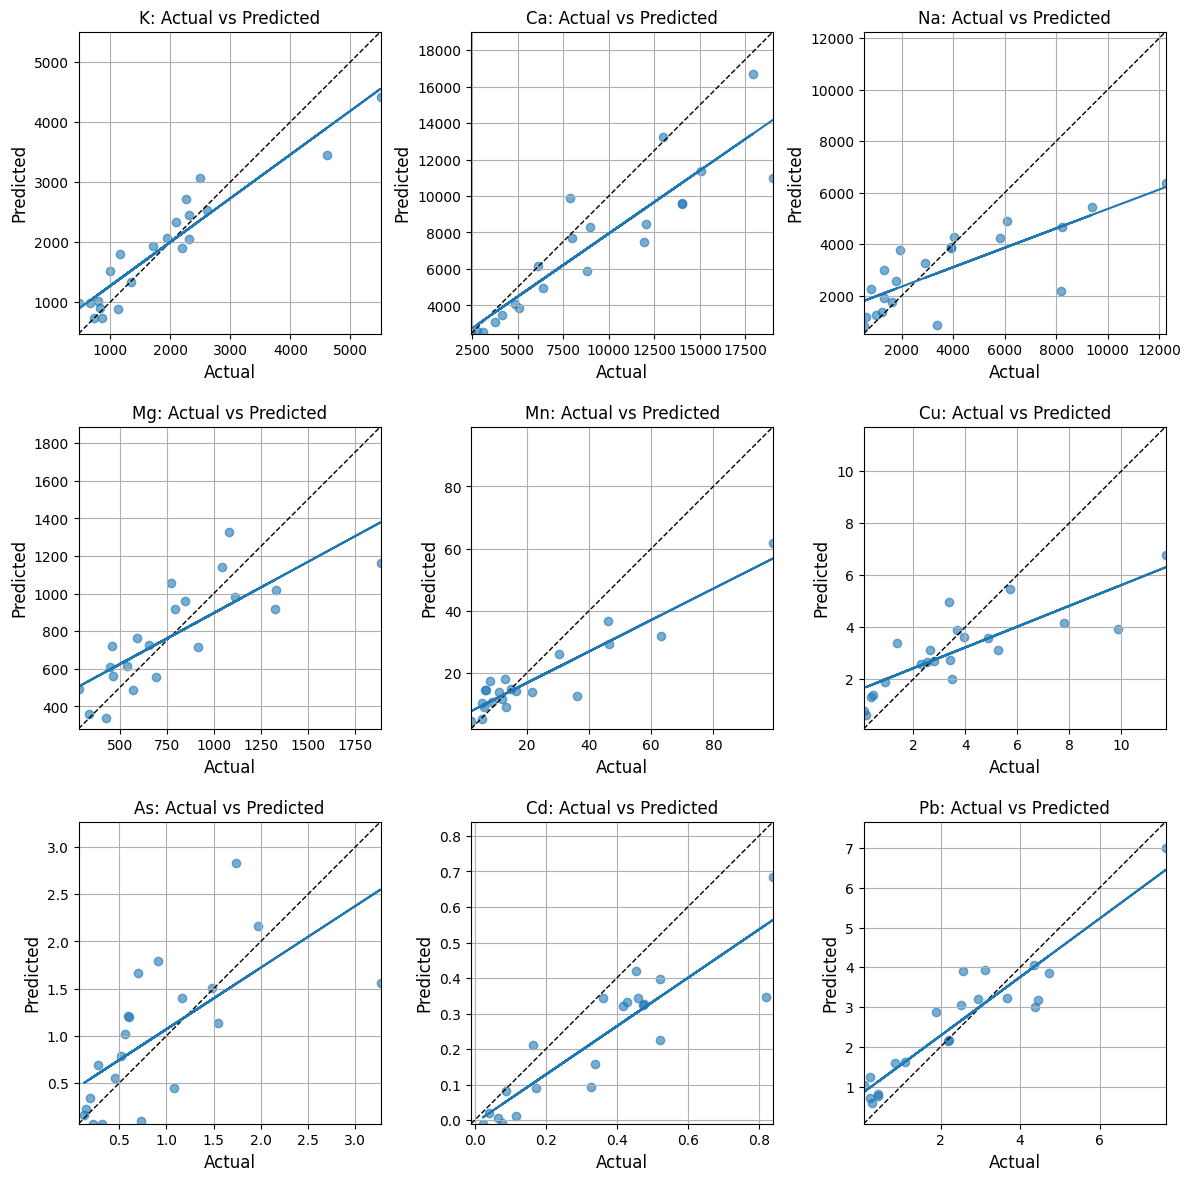

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

# Example data (replace with your actual data)
#columns = ['var1', 'var2', 'var3', 'var4', 'var5']

# Grid size
n_vars = len(B_augmented.columns)
n_cols = 3  # number of plots per row
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

# Flatten axes array for easy indexing
axes = axes.flatten()

for i, col in enumerate(B_augmented.columns):
    ax = axes[i]
    
    # Limits
    min_val = min(B_augmented[210:][col].min(), B_hat_df[col].min())#-25
    max_val = max(B_augmented[210:][col].max(), B_hat_df[col].max())#+25
    
    # 1:1 reference line
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)

    # Scatter actual vs predicted
    ax.scatter(B_augmented[210:][col], B_hat_df[col], alpha=0.6)

    #for uncertainty plot
    m,c = np.polyfit(B_augmented[210:][col].values, B_hat_df[col].values, 1)
    mx = m*B[col].values
    ax.plot(B[col].values, mx+c)
    
    ax.set_title(f'{col}: Actual vs Predicted', fontsize=12)
    ax.set_xlabel('Actual', fontsize=12)
    ax.set_ylabel('Predicted', fontsize=12)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.grid(True)
    ax.set_aspect('equal')

# Hide unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
#plt.savefig("D:/IIITK_final/IIITK/Fog_SKD/New_data/result_ind_mlp_opt_bihar.png",bbox_inches = 'tight', dpi = 600)
plt.show()

In [142]:
# Calculating intercept and coefficient

for i, col in enumerate(B.columns):
    #print(X[col].values)
    m,c = np.polyfit(B_augmented[210:][col].values, B_hat_df[col].values, 1).round(2)
    mx = m*(B_augmented[210:][col].values)
    print(B_augmented.columns[i])
    print("Y=",m,"X+",c)
    

K
Y= 0.73 X+ 539.44
Ca
Y= 0.69 X+ 1018.54
Na
Y= 0.38 X+ 1599.76
Mg
Y= 0.54 X+ 352.37
Mn
Y= 0.51 X+ 6.72
Cu
Y= 0.4 X+ 1.62
As
Y= 0.65 X+ 0.42
Cd
Y= 0.68 X+ -0.01
Pb
Y= 0.74 X+ 0.81


In [73]:
#B_hat_df.to_excel("D:/IIITK_final/IIITK/Fog_SKD/New_data/mlp_pred_new.xlsx")